<a href="https://colab.research.google.com/github/amoukrim/Python/blob/main/Week3/DailyChallenge/challengew3d2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Daly challenge : Analyse des Données de la Base de Données Mondiale des Centrales Électriques
Objective:
Apply your knowledge of NumPy, Pandas, and Matplotlib to analyze a real-world dataset. Utilize advanced statistical functions and array operations in NumPy, and integrate these with Pandas for data manipulation and Matplotlib for visualization.

In [12]:
#1. Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chargement des données avec Pandas
df = pd.read_csv("/content/global_power_plant_database.csv", encoding='latin1') # Gestion des caractères spéciaux
print("Dimensions du DataFrame :", df.shape)
print("\nAperçu des données :\n", df.head())


Dimensions du DataFrame : (34936, 36)

Aperçu des données :
   country country_long                                              name  \
0     AFG  Afghanistan      Kajaki Hydroelectric Power Plant Afghanistan   
1     AFG  Afghanistan                                      Kandahar DOG   
2     AFG  Afghanistan                                      Kandahar JOL   
3     AFG  Afghanistan     Mahipar Hydroelectric Power Plant Afghanistan   
4     AFG  Afghanistan  Naghlu Dam Hydroelectric Power Plant Afghanistan   

      gppd_idnr  capacity_mw  latitude  longitude primary_fuel other_fuel1  \
0  GEODB0040538         33.0    32.322    65.1190        Hydro         NaN   
1    WKS0070144         10.0    31.670    65.7950        Solar         NaN   
2    WKS0071196         10.0    31.623    65.7920        Solar         NaN   
3  GEODB0040541         66.0    34.556    69.4787        Hydro         NaN   
4  GEODB0040534        100.0    34.641    69.7170        Hydro         NaN   

  other_fuel2

/tmp/ipython-input-12-225386833.py:8: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/global_power_plant_database.csv", encoding='latin1') # Gestion des caractères spéciaux


In [13]:
#2 Préprocessing nettoyage de données
#Gestion des valeurs manquantes
# Vérification des NaN
missing_values = df.isnull().sum()
print("\nValeurs manquantes par colonne :\n", missing_values[missing_values > 0])

#Nettoyage Approfondi avec Stratégies pour les Nulls
# Copie du dataframe pour nettoyage
df_clean = df.copy()

# Gestion des colonnes avec trop de nulls (>50%)
threshold = len(df_clean) * 0.5
df_clean = df_clean.dropna(thresh=threshold, axis=1)

# Imputation pour les valeurs numériques
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().any():
        # Imputation par médiane pour les valeurs extrêmes
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print(f"Colonne numérique '{col}': {df_clean[col].isnull().sum()} nulls restants")

# Gestion des catégories
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df_clean[col].isnull().any():
        # Remplacement par 'Inconnu' pour les catégories
        df_clean[col] = df_clean[col].fillna('Inconnu')
        print(f"Colonne catégorielle '{col}': {df_clean[col].isnull().sum()} nulls restants")

# Vérification finale
print("\n=== Valeurs manquantes après traitement ===")
print(df_clean.isnull().sum().sum(), "nulls restants au total")





Valeurs manquantes par colonne :
 other_fuel1                      32992
other_fuel2                      34660
other_fuel3                      34844
commissioning_year               17489
owner                            14068
source                              15
url                                 18
geolocation_source                 419
wepp_id                          18702
year_of_capacity_data            20049
generation_gwh_2013              28519
generation_gwh_2014              27710
generation_gwh_2015              26733
generation_gwh_2016              25792
generation_gwh_2017              25436
generation_gwh_2018              25299
generation_gwh_2019              25277
generation_data_source           23536
estimated_generation_gwh_2013    18816
estimated_generation_gwh_2014    18433
estimated_generation_gwh_2015    17886
estimated_generation_gwh_2016    17366
estimated_generation_gwh_2017     1798
dtype: int64
Colonne numérique 'estimated_generation_gwh_2016': 0 nu


=== Statistiques de Capacité (MW) ===
count    34936.000000
mean       163.355148
std        489.636072
min          1.000000
25%          4.900000
50%         16.745000
75%         75.344250
max      22500.000000
Name: capacity_mw, dtype: float64


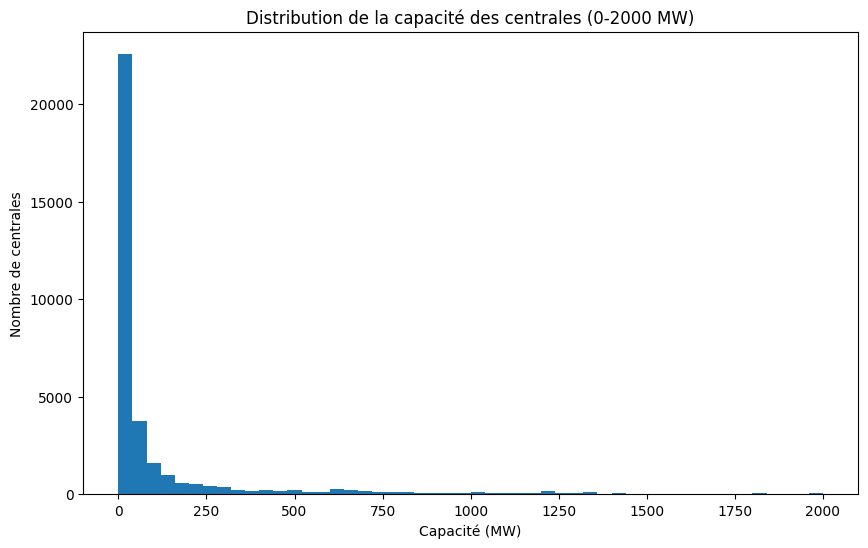

In [14]:
#3 Analyse Exploratoire avec Gestion des Résidus Nulls
# Statistiques descriptives

# Analyse de capacité avec vérification des nulls
if df_clean['capacity_mw'].isnull().sum() > 0:
    print("\nAttention: Il reste des nulls dans capacity_mw")
    df_clean = df_clean.dropna(subset=['capacity_mw'])

print("\n=== Statistiques de Capacité (MW) ===")
print(df_clean['capacity_mw'].describe())

# Visualisation de la distribution avec gestion des outliers
plt.figure(figsize=(10,6))
plt.hist(df_clean['capacity_mw'], bins=50, range=(0, 2000))
plt.title("Distribution de la capacité des centrales (0-2000 MW)")
plt.xlabel("Capacité (MW)")
plt.ylabel("Nombre de centrales")
plt.show()

In [15]:
#4. Analyse Statistique Avancée : Analyse par Combustible avec Contrôle des Données

# Vérification des données de combustible
if 'primary_fuel' not in df_clean.columns:
    print("Erreur: Colonne 'primary_fuel' manquante")
else:
    # Nettoyage supplémentaire des combustibles
    df_clean['primary_fuel'] = df_clean['primary_fuel'].str.strip().str.title()
    unknown_fuels = df_clean['primary_fuel'] == 'Inconnu'
    print(f"\n{unknown_fuels.sum()} centrales avec combustible inconnu")

    # Analyse sans les inconnus
    fuel_analysis = df_clean[~unknown_fuels]['primary_fuel'].value_counts(normalize=True) * 100
    print("\n=== Répartition par Combustible (sans inconnus) ===")
    print(fuel_analysis.head(10))


0 centrales avec combustible inconnu

=== Répartition par Combustible (sans inconnus) ===
primary_fuel
Solar         30.527250
Hydro         20.483169
Wind          15.296542
Gas           11.443783
Coal           6.669338
Oil            6.640714
Biomass        4.093199
Waste          3.057019
Nuclear        0.558163
Geothermal     0.540989
Name: proportion, dtype: float64


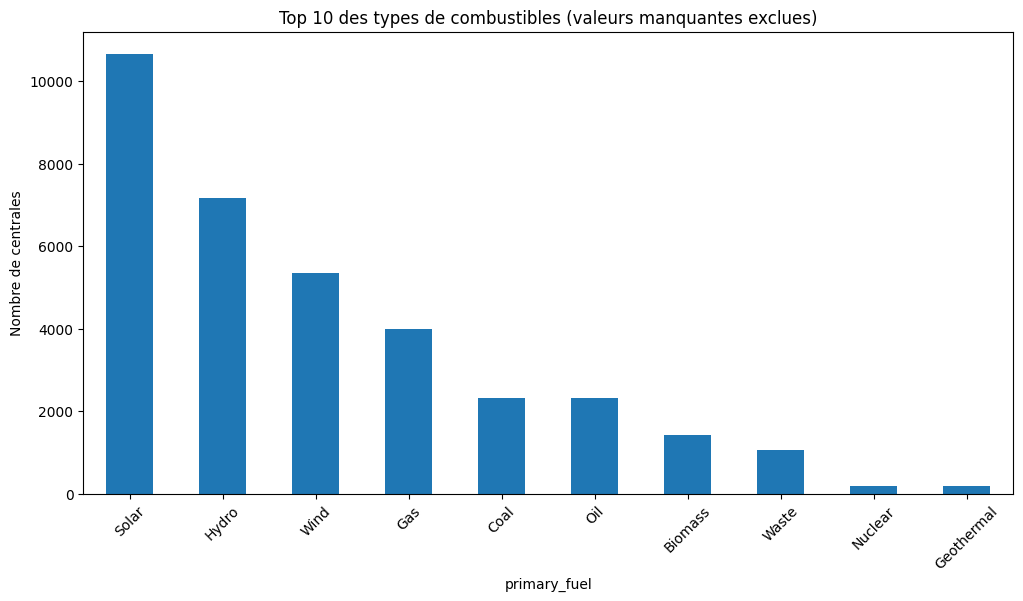

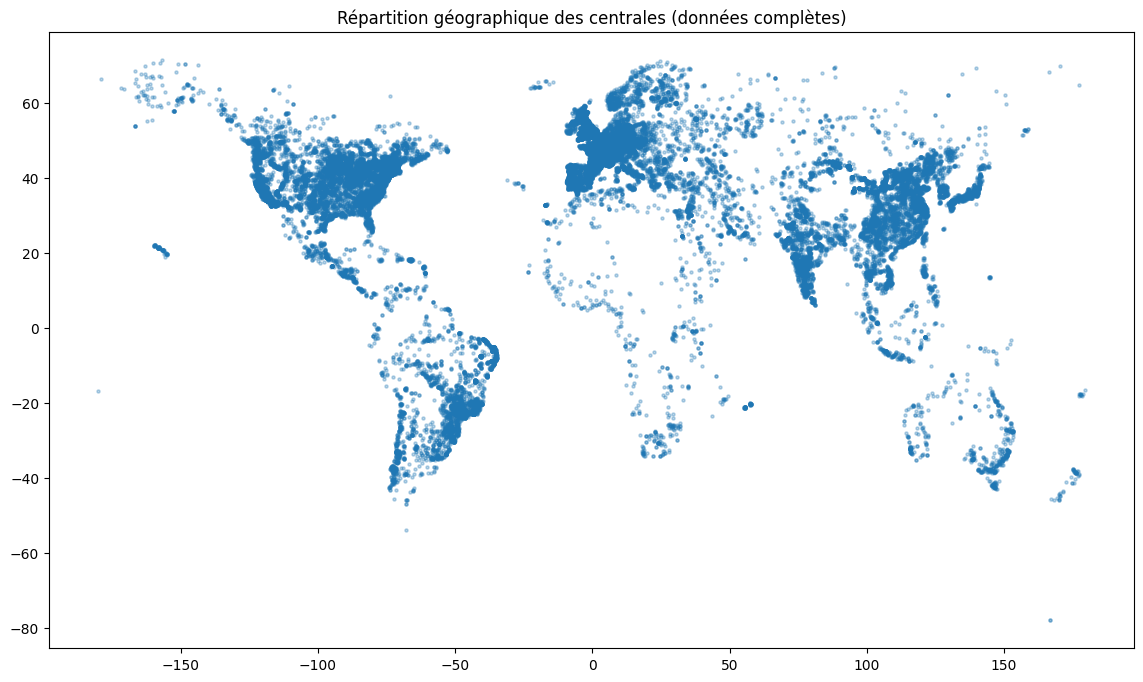

In [16]:
#5 Visualisations avec Gestion des Données Manquantes
# Graphique à barres avec gestion des nulls
plt.figure(figsize=(12,6))
df_clean['primary_fuel'].value_counts(dropna=True).head(10).plot(kind='bar')
plt.title("Top 10 des types de combustibles (valeurs manquantes exclues)")
plt.ylabel("Nombre de centrales")
plt.xticks(rotation=45)
plt.show()

# Nuage de points avec filtrage des coordonnées null
geo_clean = df_clean.dropna(subset=['latitude', 'longitude'])
plt.figure(figsize=(14,8))
plt.scatter(geo_clean['longitude'], geo_clean['latitude'], alpha=0.3, s=5)
plt.title("Répartition géographique des centrales (données complètes)")
plt.show()

In [17]:
# Export des Données Nettoyées
# Export vers nouveau fichier
df_clean.to_csv('power_plants_cleaned.csv', index=False)
print("\nDonnées nettoyées exportées vers power_plants_cleaned.csv")

# Analyse sommaire
print('analyses sommaire')
print("=== Récapitulatif de l'analyse ===\n")
print(f"Centrales analysées: {len(df_clean)}\n")
print(f"Combustible principal: {df_clean['primary_fuel'].mode()[0]}\n")
print(f"Capacité moyenne: {df_clean['capacity_mw'].mean():.2f} MW\n")



Données nettoyées exportées vers power_plants_cleaned.csv
analyses sommaire
=== Récapitulatif de l'analyse ===

Centrales analysées: 34936

Combustible principal: Solar

Capacité moyenne: 163.36 MW

